In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

In [4]:
df = pd.read_excel("Shark_Tank_India.xlsx")
print("Shape:", df.shape)
print(df.head(3))

Shape: (789, 80)
   Season Number      Startup Name  Episode Number  Pitch Number Season Start  \
0              1     BluePineFoods               1             1   2021-12-20   
1              1      BoozScooters               1             2   2021-12-20   
2              1  HeartUpMySleeves               1             3   2021-12-20   

  Season End Original Air Date                Episode Title           Anchor  \
0 2022-02-04        2021-12-20  Badlegi Business Ki Tasveer  Rannvijay Singh   
1 2022-02-04        2021-12-20  Badlegi Business Ki Tasveer  Rannvijay Singh   
2 2022-02-04        2021-12-20  Badlegi Business Ki Tasveer  Rannvijay Singh   

                       Industry  ... Invested Guest Name All Guest Names  \
0             Food and Beverage  ...      Ashneer Grover  Ashneer Grover   
1  Vehicles/Electrical Vehicles  ...      Ashneer Grover  Ashneer Grover   
2                Beauty/Fashion  ...                 NaN  Ashneer Grover   

   Namita Present  Vineeta Prese

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

Transgender Presenters    786
Amit Debt Amount          782
Guest Debt Amount         780
Anupam Debt Amount        780
Peyush Debt Amount        776
                         ... 
Number of Presenters       77
Episode Title              72
Anchor                     72
Industry                   41
Original Air Date          31
Length: 70, dtype: int64


In [6]:
# Fix date columns
date_cols = ['Season Start', 'Season End', 'Original Air Date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Fill Shark Present columns with 0
present_cols = ['Namita Present', 'Vineeta Present', 'Anupam Present',
                'Aman Present', 'Peyush Present', 'Ritesh Present',
                'Amit Present', 'Guest Present']
df[present_cols] = df[present_cols].fillna(0).astype(int)

# Fill all investment/debt/equity columns with 0
sharks = ['Namita', 'Vineeta', 'Anupam', 'Aman', 'Peyush', 'Ritesh', 'Amit', 'Guest']
for s in sharks:
    df[f"{s} Investment Amount"] = df[f"{s} Investment Amount"].fillna(0)
    df[f"{s} Investment Equity"] = df[f"{s} Investment Equity"].fillna(0)
    df[f"{s} Debt Amount"]       = df[f"{s} Debt Amount"].fillna(0)

# Fill numeric financial columns with 0
num_cols = ['Yearly Revenue', 'Monthly Sales', 'Gross Margin', 'Net Margin',
            'EBITDA', 'Cash Burn', 'SKUs', 'Total Deal Debt', 'Debt Interest',
            'Royalty Percentage', 'Total Deal Equity', 'Number of Presenters',
            'Male Presenters', 'Female Presenters', 'Transgender Presenters',
            'Couple Presenters']
df[num_cols] = df[num_cols].fillna(0)

# Fix boolean columns
df['Accepted Offer']  = df['Accepted Offer'].fillna(0).astype(int)
df['Has Patents']     = df['Has Patents'].apply(lambda x: 1 if x == 'yes' else 0)
df['Bootstrapped']    = df['Bootstrapped'].apply(lambda x: 1 if pd.notna(x) and x != '' else 0)

print("Cleaning done")
print("Remaining nulls:", df.isnull().sum().sum())

Cleaning done
Remaining nulls: 6078


In [7]:
missing2 = df.isnull().sum()
missing2 = missing2[missing2 > 0].sort_values(ascending=False)
print(missing2)

Part of Match off           775
Advisory Shares Equity      773
Deal Has Conditions         750
Royalty Recouped Amount     742
Invested Guest Name         709
All Guest Names             403
Deal Valuation              356
Total Deal Amount           355
Number of Sharks in Deal    355
Season End                  155
Started in                  150
Company Website              89
Pitchers City                88
Pitchers State               85
Pitchers Average Age         77
Anchor                       72
Episode Title                72
Industry                     41
Original Air Date            31
dtype: int64


In [8]:
# Deal Status column
def deal_status(row):
    if row['Accepted Offer'] == 1:
        return 'Deal Done'
    elif row['Received Offer'] == 1:
        return 'Offer Rejected'
    else:
        return 'No Offer'

df['Deal Status'] = df.apply(deal_status, axis=1)

# Season label
df['Season Label'] = 'Season ' + df['Season Number'].astype(str)

# Total shark investment per pitch
df['Total Shark Investment'] = df[[f"{s} Investment Amount" for s in sharks]].sum(axis=1)

print(df['Deal Status'].value_counts())
print(df['Season Label'].value_counts())

Deal Status
Deal Done         434
No Offer          289
Offer Rejected     66
Name: count, dtype: int64
Season Label
Season 2    169
Season 3    157
Season 4    156
Season 5    155
Season 1    152
Name: count, dtype: int64


In [9]:
df.to_excel("shark_tank_clean.xlsx", index=False)
print("Exported successfully")
print("Shape:", df.shape)

Exported successfully
Shape: (789, 83)


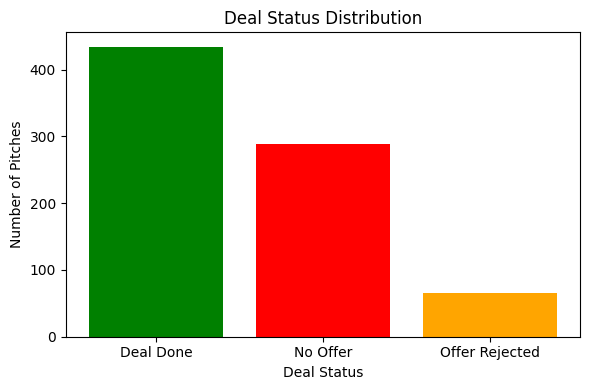

In [10]:
plt.figure(figsize=(6, 4))
deal_counts = df['Deal Status'].value_counts()
plt.bar(deal_counts.index, deal_counts.values, color=['green', 'red', 'orange'])
plt.title('Deal Status Distribution')
plt.xlabel('Deal Status')
plt.ylabel('Number of Pitches')
plt.tight_layout()
plt.show()

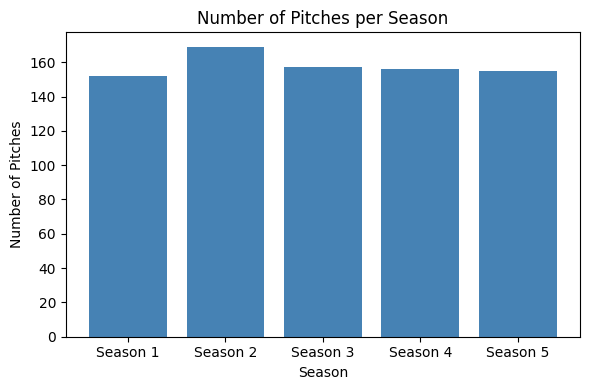

In [11]:
plt.figure(figsize=(6, 4))
season_counts = df['Season Label'].value_counts().sort_index()
plt.bar(season_counts.index, season_counts.values, color='steelblue')
plt.title('Number of Pitches per Season')
plt.xlabel('Season')
plt.ylabel('Number of Pitches')
plt.tight_layout()
plt.show()

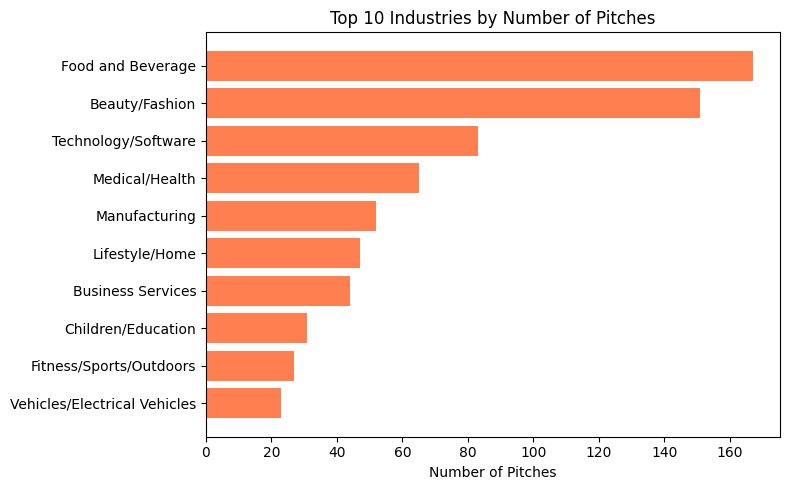

In [12]:
plt.figure(figsize=(8, 5))
industry_counts = df['Industry'].value_counts().head(10)
plt.barh(industry_counts.index, industry_counts.values, color='coral')
plt.title('Top 10 Industries by Number of Pitches')
plt.xlabel('Number of Pitches')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

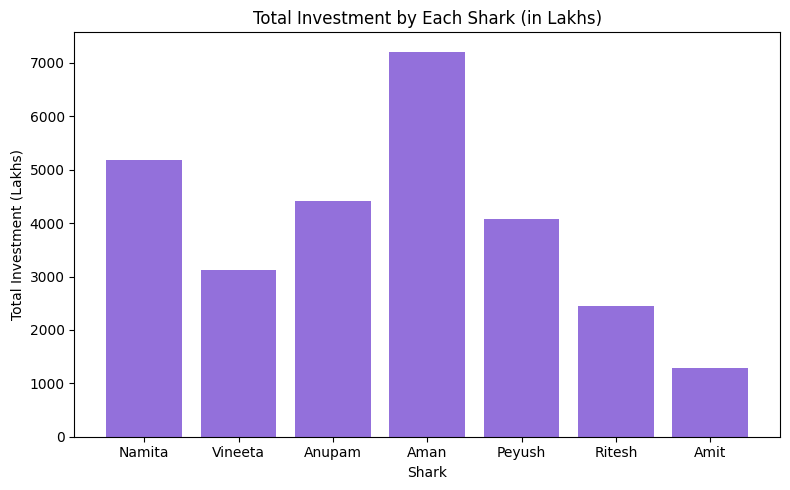

In [13]:
plt.figure(figsize=(8, 5))
shark_names = ['Namita', 'Vineeta', 'Anupam', 'Aman', 'Peyush', 'Ritesh', 'Amit']
shark_totals = [df[f"{s} Investment Amount"].sum() for s in shark_names]

plt.bar(shark_names, shark_totals, color='mediumpurple')
plt.title('Total Investment by Each Shark (in Lakhs)')
plt.xlabel('Shark')
plt.ylabel('Total Investment (Lakhs)')
plt.tight_layout()
plt.show()

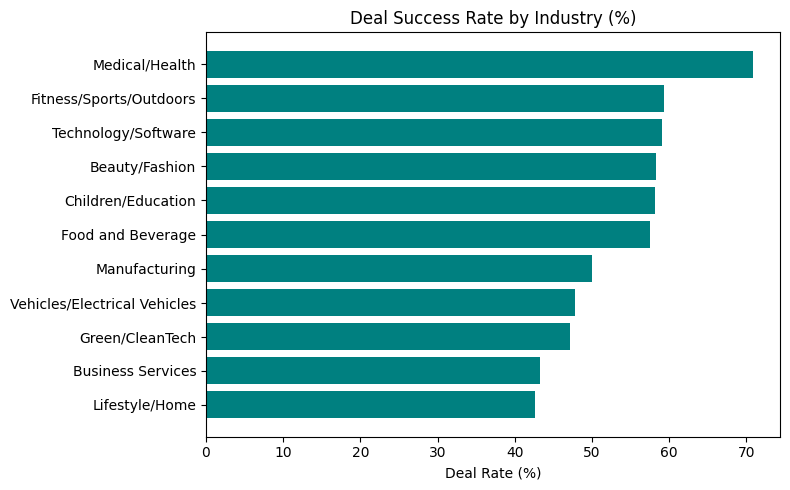

In [14]:
plt.figure(figsize=(8, 5))
industry_deal = df.groupby('Industry').agg(
    Total=('Deal Status', 'count'),
    Deals=('Accepted Offer', 'sum')
).reset_index()
industry_deal['Deal Rate'] = (industry_deal['Deals'] / industry_deal['Total'] * 100).round(1)
industry_deal = industry_deal[industry_deal['Total'] >= 10].sort_values('Deal Rate', ascending=True)

plt.barh(industry_deal['Industry'], industry_deal['Deal Rate'], color='teal')
plt.title('Deal Success Rate by Industry (%)')
plt.xlabel('Deal Rate (%)')
plt.tight_layout()
plt.show()

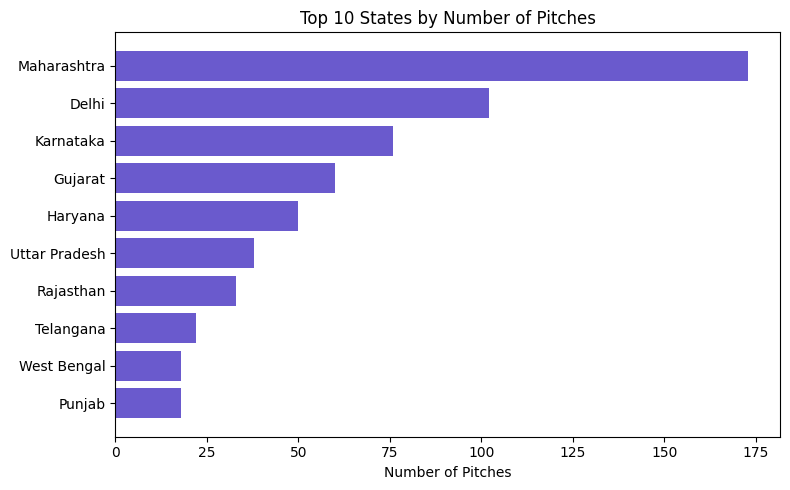

In [15]:
plt.figure(figsize=(8, 5))
state_counts = df['Pitchers State'].value_counts().head(10)
plt.barh(state_counts.index, state_counts.values, color='slateblue')
plt.title('Top 10 States by Number of Pitches')
plt.xlabel('Number of Pitches')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

df = pd.read_excel("shark_tank_clean.xlsx")

sharks = ['Namita', 'Vineeta', 'Anupam', 'Aman', 'Peyush', 'Ritesh', 'Amit']

# Create a long format dataframe with one row per shark per pitch
rows = []
for _, row in df.iterrows():
    for shark in sharks:
        if row[f'{shark} Present'] == 1:
            rows.append({
                'Startup Name': row['Startup Name'],
                'Season Number': row['Season Number'],
                'Season Label': row['Season Label'],
                'Industry': row['Industry'],
                'Deal Status': row['Deal Status'],
                'Shark Name': shark,
                'Investment Amount': row[f'{shark} Investment Amount'],
                'Investment Equity': row[f'{shark} Investment Equity'],
                'Pitchers State': row['Pitchers State'],
                'Total Deal Amount': row['Total Deal Amount'],
                'Accepted Offer': row['Accepted Offer']
            })

shark_long = pd.DataFrame(rows)
shark_long.to_excel("shark_long.xlsx", index=False)
print("Exported successfully")
print("Shape:", shark_long.shape)